In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


 1. Load raw training and testing data

In [6]:
from pathlib import Path

# Robust file loader: works with both original names and uploaded names with suffixes.
def find_file(candidates):
    for name in candidates:
        path = Path(name)
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these files were found: {candidates}")

X_train_raw = pd.read_csv(find_file(["X_train_raw.csv"]))
X_test_raw = pd.read_csv(find_file(["X_test_raw.csv"]))
y_train = pd.read_csv(find_file(["y_train.csv"]))
y_test = pd.read_csv(find_file(["y_test.csv"]))

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_raw shape: (3341, 10)
X_test_raw shape: (836, 10)
y_train shape: (3341, 1)
y_test shape: (836, 1)


2. Create target variable: Age = Rings + 1.5

In [7]:
y_train_age = y_train["Rings"] + 1.5
y_test_age = y_test["Rings"] + 1.5


3. Prepare raw X data for XGBoost


In [8]:
X_train_xgb = X_train_raw.copy()
X_test_xgb = X_test_raw.copy()

bool_cols = X_train_xgb.select_dtypes(include=["bool"]).columns

X_train_xgb[bool_cols] = X_train_xgb[bool_cols].astype(int)
X_test_xgb[bool_cols] = X_test_xgb[bool_cols].astype(int)

4. Train XGBoost Regressor

In [9]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

xgb_model.fit(X_train_xgb, y_train_age)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=1, num_parallel_tree=None, ...)

5. Predict age on testing data

In [10]:
xgb_pred_age = xgb_model.predict(X_test_xgb)

6. Evaluate model performance

In [11]:
mae = mean_absolute_error(y_test_age, xgb_pred_age)
mse = mean_squared_error(y_test_age, xgb_pred_age)
r2 = r2_score(y_test_age, xgb_pred_age)

results = pd.DataFrame({
    "Model": ["XGBoost global raw"],
    "MAE": [mae],
    "MSE": [mse],
    "R2": [r2]
})

print("\n================ XGBoost Global Model Performance ================")
print(results)


================ XGBoost Global Model Performance ================
                Model       MAE       MSE        R2
0  XGBoost global raw  1.561547  4.987155  0.539302


7. Save prediction results

In [12]:
predictions = X_test_raw.copy()
predictions["Actual_Rings"] = y_test["Rings"]
predictions["Actual_Age"] = y_test_age
predictions["Predicted_Age_XGBoost_Global"] = xgb_pred_age
predictions["Residual"] = predictions["Actual_Age"] - predictions["Predicted_Age_XGBoost_Global"]
predictions["Absolute_Error"] = abs(predictions["Residual"])

predictions.to_csv("xgboost_predictions.csv", index=False)
results.to_csv("xgboost_model_performance.csv", index=False)

8. Feature importance


================ XGBoost Feature Importance ================
          Feature  Importance
6    Shell_weight    0.393595
2          Height    0.122715
8           Sex_I    0.113508
4  Shucked_weight    0.106470
7           Sex_F    0.065627
3    Whole_weight    0.059737
1        Diameter    0.045566
5  Viscera_weight    0.039284
0          Length    0.037823
9           Sex_M    0.015672


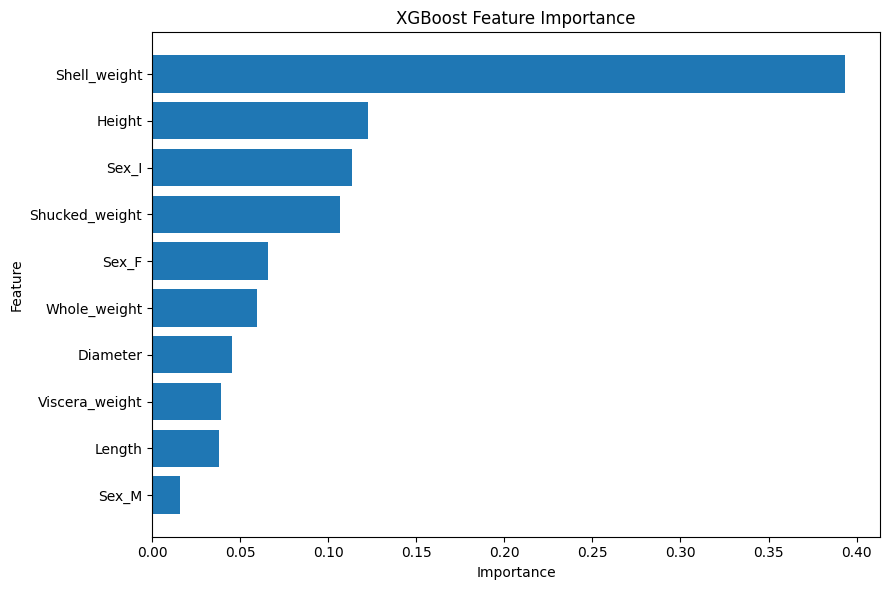

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X_train_xgb.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n================ XGBoost Feature Importance ================")
print(feature_importance)

feature_importance.to_csv("xgboost_feature_importance.csv", index=False)
# Feature importance plot
plt.figure(figsize=(9, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig("xgboost_feature_importance.png", dpi=300)
plt.show()

9. Age range error analysis


================ XGBoost Error by Age Range ================
              Age_Range  Sample_Size       MAE        MSE  Mean_Actual_Age  \
0      Young age <= 7.5           96  0.997328   1.552284         6.802083   
1   Medium age 8.5-10.5          325  1.219139   2.447676         9.678462   
2     Old age 11.5-13.5          283  1.246176   2.799867        12.189046   
3  Very old age >= 14.5          132  3.491076  18.427160        17.227273   

   Mean_Predicted_Age  
0            7.496109  
1           10.593078  
2           12.395069  
3           14.017708  


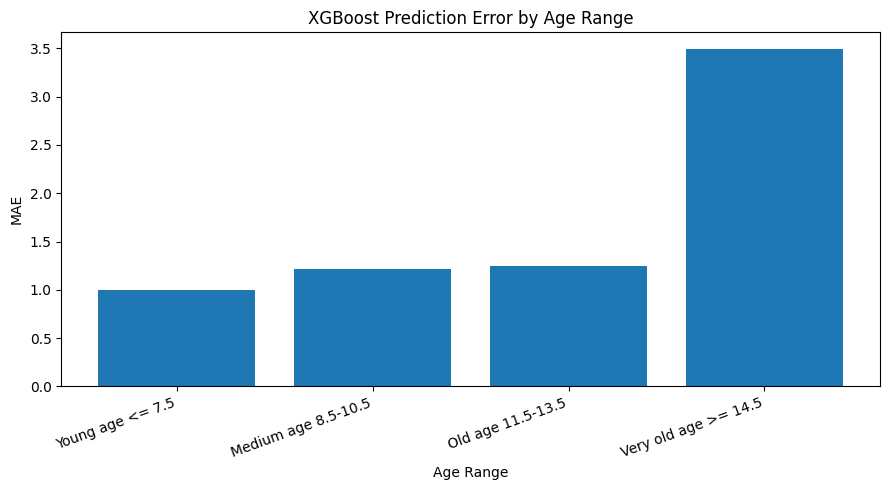

In [14]:
predictions["Age_Range"] = pd.cut(
    predictions["Actual_Age"],
    bins=[0, 7.5, 10.5, 13.5, np.inf],
    labels=[
        "Young age <= 7.5",
        "Medium age 8.5-10.5",
        "Old age 11.5-13.5",
        "Very old age >= 14.5"
    ]
)

age_range_errors = predictions.groupby("Age_Range", observed=False).agg(
    Sample_Size=("Actual_Age", "count"),
    MAE=("Absolute_Error", "mean"),
    MSE=("Residual", lambda x: np.mean(x ** 2)),
    Mean_Actual_Age=("Actual_Age", "mean"),
    Mean_Predicted_Age=("Predicted_Age_XGBoost_Global", "mean")
).reset_index()

print("\n================ XGBoost Error by Age Range ================")
print(age_range_errors)

age_range_errors.to_csv("xgboost_age_range_errors.csv", index=False)

# Age range error plot
plt.figure(figsize=(9, 5))
plt.bar(age_range_errors["Age_Range"].astype(str), age_range_errors["MAE"])
plt.xlabel("Age Range")
plt.ylabel("MAE")
plt.title("XGBoost Prediction Error by Age Range")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("xgboost_age_range_errors.png", dpi=300)
plt.show()

11. Global Strategy vs. Local Strategy by Sex

The global strategy trains one XGBoost model using all observations. The local strategy trains three separate XGBoost models for F, I and M groups, then compares the metrics for each group.

In [15]:
# Global strategy vs. Local strategy by Sex
# This follows the same idea as the Random Forest notebook,
# but applies it to the XGBoost model.

xgb_params = dict(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

def get_sex_label(row):
    if row["Sex_I"] == 1:
        return "I"
    if row["Sex_F"] == 1:
        return "F"
    return "M"

X_train_sex = X_train_xgb.copy()
X_test_sex = X_test_xgb.copy()
X_train_sex["Sex"] = X_train_sex.apply(get_sex_label, axis=1)
X_test_sex["Sex"] = X_test_sex.apply(get_sex_label, axis=1)

genders = ["F", "I", "M"]
comparison_results = []

for sex in genders:
    # Test subset for this Sex group
    idx_test = X_test_sex["Sex"] == sex
    X_test_sub = X_test_xgb[idx_test]
    y_test_sub = y_test_age[idx_test]

    # Global evaluation: use the original XGBoost model trained on all groups
    y_pred_global = xgb_model.predict(X_test_sub)
    global_mae = mean_absolute_error(y_test_sub, y_pred_global)
    global_mse = mean_squared_error(y_test_sub, y_pred_global)
    global_r2 = r2_score(y_test_sub, y_pred_global)

    # Local evaluation: train one XGBoost model using only this Sex group
    idx_train = X_train_sex["Sex"] == sex
    xgb_local = XGBRegressor(**xgb_params)
    xgb_local.fit(X_train_xgb[idx_train], y_train_age[idx_train])
    y_pred_local = xgb_local.predict(X_test_sub)
    local_mae = mean_absolute_error(y_test_sub, y_pred_local)
    local_mse = mean_squared_error(y_test_sub, y_pred_local)
    local_r2 = r2_score(y_test_sub, y_pred_local)

    comparison_results.append({
        "Sex": sex,
        "Train_Sample_Size": int(idx_train.sum()),
        "Test_Sample_Size": int(idx_test.sum()),
        "Global_MAE": global_mae,
        "Local_MAE": local_mae,
        "Global_MSE": global_mse,
        "Local_MSE": local_mse,
        "Global_R2": global_r2,
        "Local_R2": local_r2,
        "MAE_Change_Local_minus_Global": local_mae - global_mae,
        "Better_Strategy_By_MAE": "Local" if local_mae < global_mae else "Global"
    })

comp_df = pd.DataFrame(comparison_results)

print("\n================ XGBoost Global vs Local Strategy Comparison ================")
print(comp_df)

comp_df.to_csv("xgboost_global_local_strategy_comparison.csv", index=False)


================ XGBoost Global vs Local Strategy Comparison ================
  Sex  Train_Sample_Size  Test_Sample_Size  Global_MAE  Local_MAE  Global_MSE  \
0   F               1045               262    1.944667   1.917866    7.142129   
1   I               1075               267    1.027025   1.087141    1.942118   
2   M               1221               307    1.699462   1.742543    5.796345   

   Local_MSE  Global_R2  Local_R2  MAE_Change_Local_minus_Global  \
0   6.944223   0.330328  0.348884                      -0.026801   
1   2.657088   0.572413  0.415002                       0.060115   
2   5.774092   0.363514  0.365958                       0.043081   

  Better_Strategy_By_MAE  
0                  Local  
1                 Global  
2                 Global  


12. Visualise Global vs. Local Strategy Comparison

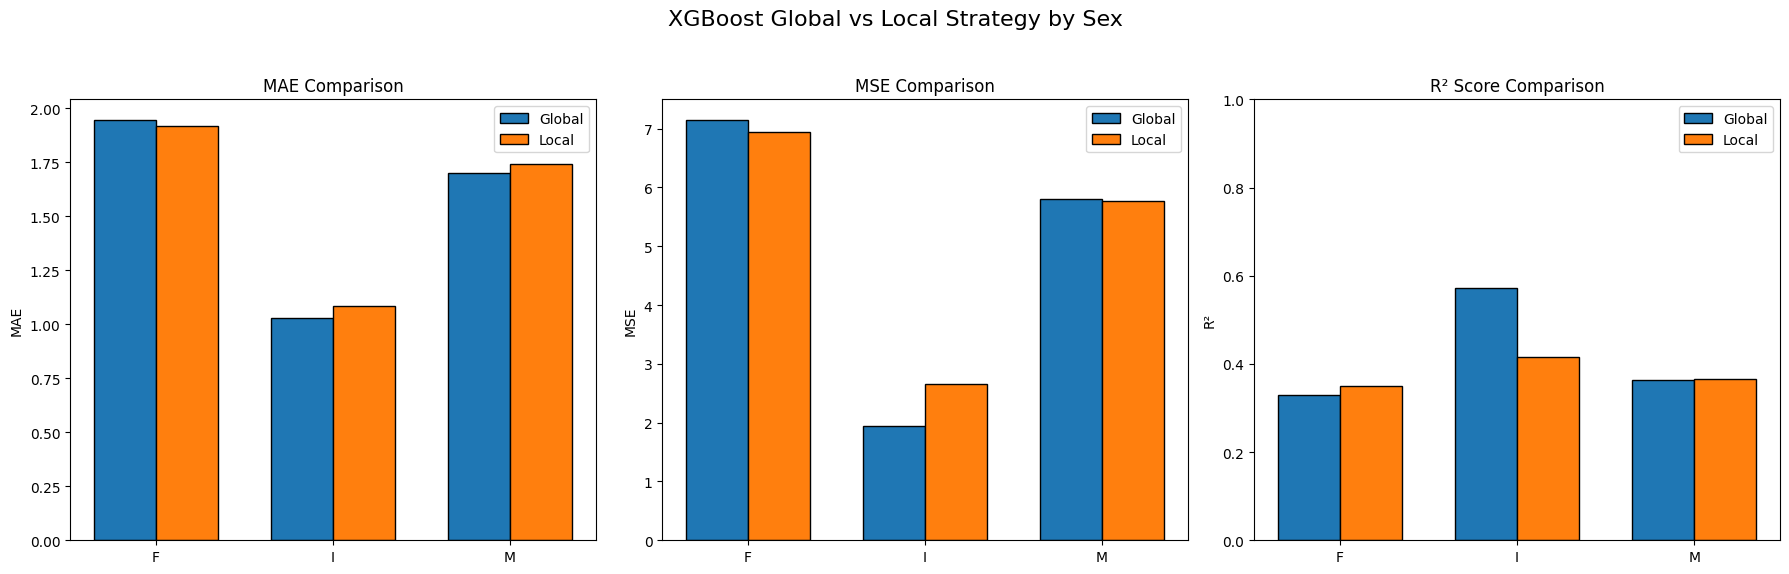

In [16]:
# Visual comparison of Global vs. Local performance
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(genders))
width = 0.35

# MAE comparison: lower is better
ax1.bar(x - width/2, comp_df["Global_MAE"], width, label="Global", edgecolor="black")
ax1.bar(x + width/2, comp_df["Local_MAE"], width, label="Local", edgecolor="black")
ax1.set_title("MAE Comparison")
ax1.set_xticks(x)
ax1.set_xticklabels(genders)
ax1.set_ylabel("MAE")
ax1.legend()

# MSE comparison: lower is better
ax2.bar(x - width/2, comp_df["Global_MSE"], width, label="Global", edgecolor="black")
ax2.bar(x + width/2, comp_df["Local_MSE"], width, label="Local", edgecolor="black")
ax2.set_title("MSE Comparison")
ax2.set_xticks(x)
ax2.set_xticklabels(genders)
ax2.set_ylabel("MSE")
ax2.legend()

# R2 comparison: higher is better
ax3.bar(x - width/2, comp_df["Global_R2"], width, label="Global", edgecolor="black")
ax3.bar(x + width/2, comp_df["Local_R2"], width, label="Local", edgecolor="black")
ax3.set_title("R² Score Comparison")
ax3.set_xticks(x)
ax3.set_xticklabels(genders)
ax3.set_ylabel("R²")
ax3.set_ylim(min(0, comp_df[["Global_R2", "Local_R2"]].min().min() - 0.05), 1)
ax3.legend()

plt.suptitle("XGBoost Global vs Local Strategy by Sex", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("xgboost_global_local_strategy_comparison.png", dpi=300)
plt.show()

13. Short Global vs. Local Strategy Summary

In [17]:
local_wins = (comp_df["Better_Strategy_By_MAE"] == "Local").sum()
global_wins = (comp_df["Better_Strategy_By_MAE"] == "Global").sum()

strategy_summary_text = f"""
XGBoost Global vs Local Strategy Summary

Overall global XGBoost performance:
MAE = {mae:.3f}
MSE = {mse:.3f}
R2 = {r2:.3f}

By-sex comparison based on MAE:
{comp_df[["Sex", "Train_Sample_Size", "Test_Sample_Size", "Global_MAE", "Local_MAE", "MAE_Change_Local_minus_Global", "Better_Strategy_By_MAE"]].to_string(index=False)}

Interpretation:
The global strategy trains one XGBoost model using all F, I and M samples.
The local strategy trains three separate XGBoost models, one for each Sex group.
In this run, the global strategy is better for {global_wins} group(s), while the local strategy is better for {local_wins} group(s), based on lower MAE.
A negative MAE change means the local model improved over the global model. A positive value means the global model was better.
"""

with open("xgboost_global_local_strategy_summary.txt", "w", encoding="utf-8") as f:
    f.write(strategy_summary_text)

print("\n================ Global vs Local Strategy Summary ================")
print(strategy_summary_text)


================ Global vs Local Strategy Summary ================

XGBoost Global vs Local Strategy Summary

Overall global XGBoost performance:
MAE = 1.562
MSE = 4.987
R2 = 0.539

By-sex comparison based on MAE:
Sex  Train_Sample_Size  Test_Sample_Size  Global_MAE  Local_MAE  MAE_Change_Local_minus_Global Better_Strategy_By_MAE
  F               1045               262    1.944667   1.917866                      -0.026801                  Local
  I               1075               267    1.027025   1.087141                       0.060115                 Global
  M               1221               307    1.699462   1.742543                       0.043081                 Global

Interpretation:
The global strategy trains one XGBoost model using all F, I and M samples.
The local strategy trains three separate XGBoost models, one for each Sex group.
In this run, the global strategy is better for 2 group(s), while the local strategy is better for 1 group(s), based on lower MAE.
A negative

10. Save the trained XGBoost model

In [18]:
xgb_model.save_model("xgboost_abalone_age_model.json")

14. Short investigation summary for report writing

In [19]:
top_features = feature_importance.head(5)["Feature"].tolist()
most_difficult_range = age_range_errors.sort_values("MAE", ascending=False).iloc[0]

summary_text = f"""
XGBoost Investigation Summary

1. Model used:
XGBoost Regressor was used to predict abalone age using raw physical measurements.

2. Target variable:
Age = Rings + 1.5

3. Model performance:
MAE = {mae:.3f}
MSE = {mse:.3f}
R2 = {r2:.3f}

4. Important physical measurements:
The top five most important features in the XGBoost model were:
{top_features}

5. Challenging age range:
The most difficult age range to predict was:
{most_difficult_range["Age_Range"]}
with MAE = {most_difficult_range["MAE"]:.3f}

"""

with open("xgboost_investigation_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\n================ Investigation Summary ================")
print(summary_text)

print("\nAll XGBoost output files have been saved successfully.")



================ Investigation Summary ================

XGBoost Investigation Summary

1. Model used:
XGBoost Regressor was used to predict abalone age using raw physical measurements.

2. Target variable:
Age = Rings + 1.5

3. Model performance:
MAE = 1.562
MSE = 4.987
R2 = 0.539

4. Important physical measurements:
The top five most important features in the XGBoost model were:
['Shell_weight', 'Height', 'Sex_I', 'Shucked_weight', 'Sex_F']

5. Challenging age range:
The most difficult age range to predict was:
Very old age >= 14.5
with MAE = 3.491



All XGBoost output files have been saved successfully.
